## Unit 8. Neural Networks and Deep Learning

Fashion classification using images

### 8.1 Fashion Classification

![image.png](attachment:c294b85e-a99d-4eb8-9781-64ecad281537.png)

Theory:
https://cs231n.github.io/

### 8.2 TensorFlow and Keras

- Installing TensorFlow
- Loading images

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
from tensorflow.keras.preprocessing.image import load_img

In [47]:
#!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

In [5]:
path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
fullname = f'{path}/{name}'
fullname

'./clothing-dataset-small/train/t-shirt/5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

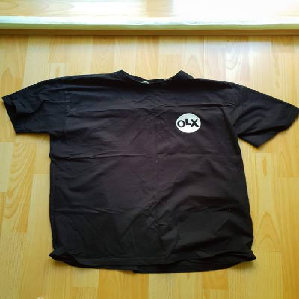

In [6]:
img = load_img(fullname, target_size=(299, 299))
img

Why to specify the size
![image.png](attachment:e2e64cf1-7df9-4526-a58d-ab608a0f2328.png)

In [7]:
# Translating the image into a numpy array
x = np.array(img)
x.shape

(299, 299, 3)

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 254, 247]],

       [[188, 179, 112],
        [187, 178, 111],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 191, 126],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  25],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]], dtype=uint8)
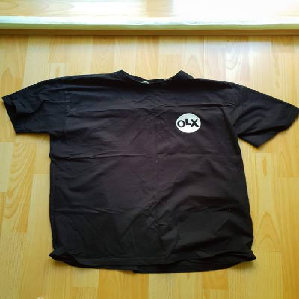

In [8]:
x

### 8.3 Pre-trained convolutional neural networks

Imagenet datasets: image-net.org

Pre-trained models: keras.io/api/applications

In [9]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [10]:
model = Xception(weights='imagenet', input_shape=(299,299,3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
# Putting an image into an array of images because the model expects a batch of images
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [12]:
# The image should be preprocessed to make sense
X = preprocess_input(X)

In [13]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


array([[3.23711836e-04, 1.57383591e-04, 2.13492880e-04, 1.52370281e-04,
        2.47625838e-04, 3.05035559e-04, 3.20591673e-04, 1.47499086e-04,
        2.03621545e-04, 1.49272208e-04, 1.95662607e-04, 2.10137077e-04,
        7.59263858e-05, 1.13972041e-04, 1.62683296e-04, 2.04638316e-04,
        1.97415691e-04, 1.44288526e-04, 1.40217293e-04, 1.73685708e-04,
        7.46689271e-04, 2.56966392e-04, 2.66808463e-04, 2.96513783e-04,
        3.73601768e-04, 2.77403975e-04, 2.16570537e-04, 2.27269804e-04,
        3.80812591e-04, 1.72165688e-04, 3.05400725e-04, 1.96431050e-04,
        3.92114598e-04, 4.78070986e-04, 2.91751028e-04, 3.25693021e-04,
        1.47395025e-04, 1.62361830e-04, 2.12710467e-04, 1.34028072e-04,
        2.40070149e-04, 6.75210846e-04, 2.54943065e-04, 1.44478545e-04,
        4.12820926e-04, 2.04408367e-04, 3.02957924e-04, 1.49339408e-04,
        1.99653441e-04, 2.27005512e-04, 2.93728866e-04, 2.27444340e-04,
        6.37643505e-04, 7.82614225e-04, 2.49556906e-04, 4.052702

In [14]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [15]:
# Deoding predictions for human-readable format
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

### 8.4 Convolutional neural networks

- Types of layers: convolutional and dense
- Convolutional layers and filters
- Dense layers

![image.png](attachment:6a2df8f1-b89a-4489-a818-57736b93b37a.png)

Filters - small images that contain simple shapes. We calculate similarity of the filter with particular part of the image
![image.png](attachment:f074efc3-741a-4773-ac07-2ac042c162db.png)

One feature map per filter
![image.png](attachment:f769599f-5827-4b77-b8aa-f67b750d3091.png)

Each new level introduces more complex filters that often combine simpler filters
![image.png](attachment:e2b3aca8-f488-4581-b9ec-d8f7f0cbc339.png)

![image.png](attachment:37ed301c-e1a2-465f-a309-28f49d251be6.png)

Dense layer is just matrix multiplication
![image.png](attachment:863cb2f2-25a9-46dd-9341-216f9f170837.png)

### 8.5 Transfer learning

Model needs to see a lot of images to come up with filters that make sense.

We want to keep the convolutional layers and retrain the model to get new dense layers
![image.png](attachment:dc6ea136-c4b3-447e-a1ee-8ede52dc7c6e.png)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [18]:
# Using smaller images to make training faster
train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train',
                                         target_size=(150, 150),
                                         batch_size=32)

Found 3068 images belonging to 10 classes.


In [19]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [20]:
# Looking what dataset generates
X, y = next(train_ds)

In [21]:
X

array([[[[ 0.11372554,  0.07450986,  0.02745104],
         [ 0.11372554,  0.07450986,  0.02745104],
         [ 0.11372554,  0.07450986,  0.02745104],
         ...,
         [ 0.60784316,  0.6       ,  0.5686275 ],
         [ 0.60784316,  0.6       ,  0.5686275 ],
         [ 0.60784316,  0.6       ,  0.5686275 ]],

        [[ 0.14509809,  0.10588241,  0.05882359],
         [ 0.14509809,  0.10588241,  0.05882359],
         [ 0.14509809,  0.10588241,  0.05882359],
         ...,
         [ 0.5921569 ,  0.58431375,  0.5529412 ],
         [ 0.6156863 ,  0.60784316,  0.5764706 ],
         [ 0.62352943,  0.6156863 ,  0.58431375]],

        [[ 0.12941182,  0.09019613,  0.04313731],
         [ 0.14509809,  0.10588241,  0.05882359],
         [ 0.15294123,  0.11372554,  0.06666672],
         ...,
         [ 0.6313726 ,  0.62352943,  0.5921569 ],
         [ 0.6313726 ,  0.62352943,  0.5921569 ],
         [ 0.6313726 ,  0.62352943,  0.5921569 ]],

        ...,

        [[ 0.12941182,  0.12156868,  0

In [22]:
X.shape

(32, 150, 150, 3)

In [23]:
# Target variable - one-hot encoding is used for labels
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [59]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory('./clothing-dataset-small/validation',
                                       target_size=(150, 150),
                                       batch_size=32,
                                       shuffle=False)

Found 341 images belonging to 10 classes.


In [25]:
# Keeping convolutional layers from Xception model
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3))

base_model.trainable=False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


![image.png](attachment:10ec8f5f-7d78-4a41-91c9-a665f7e137ae.png)

In [26]:
# # STEP 1 only
# # Creating new top
# inputs = keras.Input(shape=(150, 150, 3))

# # Apply base model to inputs and get something we will call Base
# base = base_model(inputs)

# # Wrap everything into Keras model
# outputs = base

# model = keras.Model(inputs, outputs)

In [27]:
# preds = model.predict(X)

In [28]:
# preds.shape

![image.png](attachment:1309070a-d124-44f4-bbe7-30d70de3afb3.png)

In [29]:
# # FIRST TWO STEPS ONLY
# # Creating new top
# inputs = keras.Input(shape=(150, 150, 3))

# # Apply base model to inputs and get something we will call Base
# base = base_model(inputs)

# # Using 2D pooling
# # pooling = keras.layers.GlobalAveragePooling2D()
# # vectors = pooling(base)

# # Or even better - using functional style
# vectors = keras.layers.GlobalAveragePooling2D()(base)

# # Wrap everything into Keras model
# outputs = vectors

# model = keras.Model(inputs, outputs)

# preds = model.predict(X)

# preds.shape

![image.png](attachment:63c212e8-f414-4ed2-b347-f833c402689a.png)

In [30]:
# FIRST TWO STEPS ONLY
# Creating new top
inputs = keras.Input(shape=(150, 150, 3))

# Apply base model to inputs and get something we will call Base
base = base_model(inputs, training=False)

# Or even better - using functional style
vectors = keras.layers.GlobalAveragePooling2D()(base)

# Wrap everything into Keras model
outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

preds = model.predict(X)

preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


(32, 10)

#### This new model has the dense layer filled with random numbers. We need to train it

In [31]:
# Optimiser picks the best weights
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

![image.png](attachment:6fe9e9a1-bf22-4b59-b8ef-a52925a8fb5d.png)

In [32]:
# Compile the model before training
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [33]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 371ms/step - accuracy: 0.5721 - loss: 1.6143 - val_accuracy: 0.7801 - val_loss: 0.7913
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8363 - loss: 0.4904 - val_accuracy: 0.7859 - val_loss: 0.8766
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8788 - loss: 0.3590 - val_accuracy: 0.7889 - val_loss: 0.8626
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9166 - loss: 0.2426 - val_accuracy: 0.8182 - val_loss: 0.8715
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9421 - loss: 0.1666 - val_accuracy: 0.8035 - val_loss: 0.9306
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9711 - loss: 0.0883 - val_accuracy: 0.7947 - val_loss: 0.9423
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9777 - loss: 0.0711 - val_accuracy: 0.7918 - val_loss: 0.9993
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9877 - loss: 0.0463 - val_accuracy: 0.7889 - val_loss: 

### 8.6 Adjusting the Learning Rate

What the learning rate is
![image.png](attachment:22c7a7b6-65e1-4c9e-851b-65ae7d7179ed.png)

In [34]:
def make_model(learning_rate=0.01):
    base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(150, 150, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    # Wrap everything into Keras model
    outputs = keras.layers.Dense(10)(vectors)

    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy'])

    return model

In [35]:
# Training - itterate over different values of learning rate
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 200ms/step - accuracy: 0.2108 - loss: 2.2064 - val_accuracy: 0.5015 - val_loss: 1.5989
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.5430 - loss: 1.4746 - val_accuracy: 0.6100 - val_loss: 1.2379
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6130 - loss: 1.2030 - val_accuracy: 0.6774 - val_loss: 1.0502
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6687 - loss: 1.0536 - val_accuracy: 0.7038 - val_loss: 0.9396
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7223 - loss: 0.9202 - val_accuracy: 0.7390 - val_loss: 0.8639
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.7230 - loss: 0.8763 - val_accuracy: 0.7625 - val_loss: 0.8160
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7548 - loss: 0.7975 - val_accuracy: 0.7742 - val_loss: 0.7746
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7649 - loss: 0.7729 - val_accuracy: 0

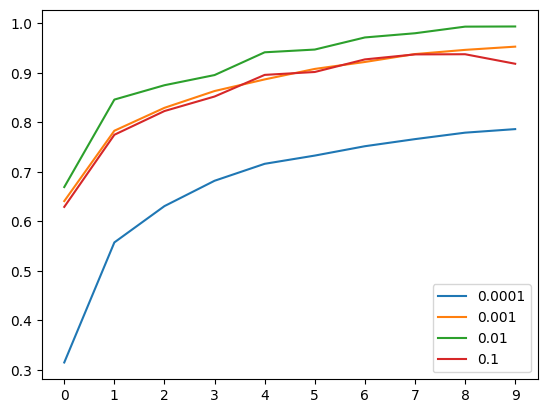

In [36]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

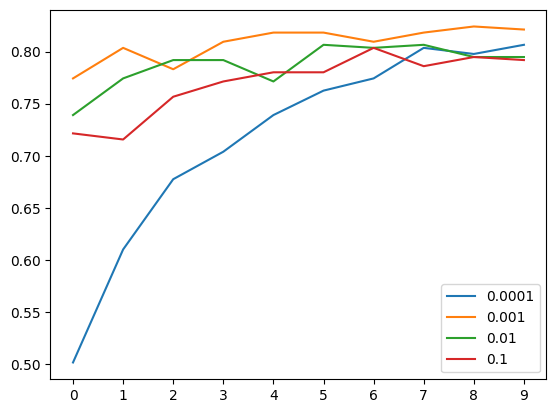

In [37]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

In [38]:
del scores[0.1]
del scores[0.0001]

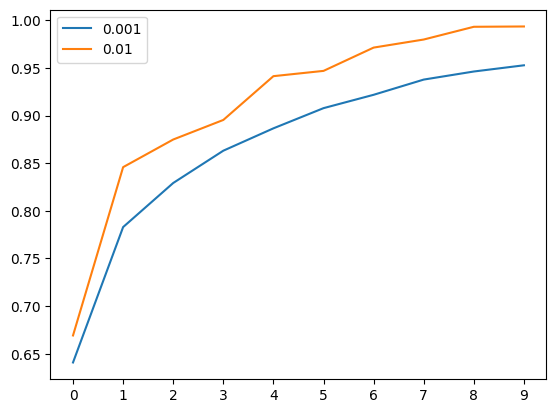

In [39]:
for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

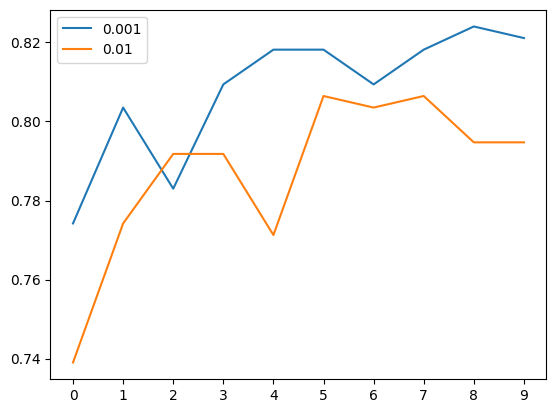

In [40]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)

plt.xticks(np.arange(10))
plt.legend()

In [41]:
# Best learning rate is
learning_rate = 0.001

### 8.7 Checkpointing

Saving our model on certain conditions

In [42]:
# Callbacks to save the best model based on the maximum accuracy
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [43]:
learning_rate = 0.001

model = make_model(learning_rate=lr)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5754 - loss: 1.6014

96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.5763 - loss: 1.5975 - val_accuracy: 0.7683 - val_loss: 0.7481
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8509 - loss: 0.4705

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8507 - loss: 0.4711 - val_accuracy: 0.8006 - val_loss: 0.7513
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9019 - loss: 0.2716 - val_accuracy: 0.7918 - val_loss: 0.8770
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9043 - loss: 0.2847 - val_accuracy: 0.7654 - val_loss: 1.0840
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9257 - loss: 0.2150

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9257 - loss: 0.2148 - val_accuracy: 0.8123 - val_loss: 0.9856
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9622 - loss: 0.1015 - val_accuracy: 0.8065 - val_loss: 0.9010
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9704 - loss: 0.0852 - val_accuracy: 0.8094 - val_loss: 1.0220
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9787 - loss: 0.0706

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9787 - loss: 0.0705 - val_accuracy: 0.8152 - val_loss: 0.8705
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9954 - loss: 0.0258

96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9953 - loss: 0.0259 - val_accuracy: 0.8182 - val_loss: 0.9291
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9988 - loss: 0.0191 - val_accuracy: 0.8094 - val_loss: 0.9403


### 8.8 Adding more layers

In [53]:
# Adding layers

def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(150, 150, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    # New layers
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    # Wrap everything into Keras model
    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy'])

    return model

In [54]:
# Training - itterate over different values of layer size
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - accuracy: 0.3956 - loss: 1.7622 - val_accuracy: 0.6569 - val_loss: 1.0792
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.6885 - loss: 0.9407 - val_accuracy: 0.7654 - val_loss: 0.7935
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.7622 - loss: 0.7000 - val_accuracy: 0.7830 - val_loss: 0.6803
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8226 - loss: 0.5388 - val_accuracy: 0.7947 - val_loss: 0.6048
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8596 - loss: 0.4393 - val_accuracy: 0.7977 - val_loss: 0.5918
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.8905 - loss: 0.3756 - val_accuracy: 0.8065 - val_loss: 0.5780
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8989 - loss: 0.3495 - val_accuracy: 0.7947 - val_loss: 0.5651
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9252 - loss: 0.2943 - val_accuracy: 0.821

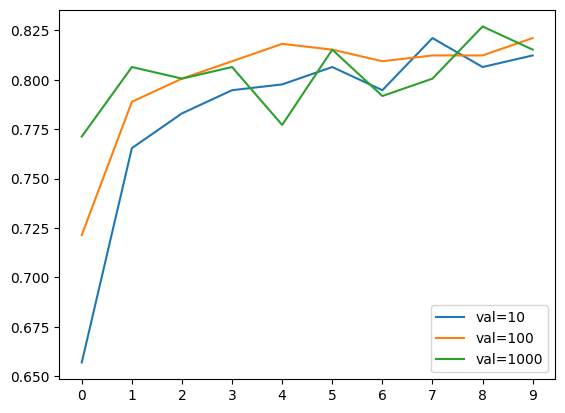

In [55]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.legend()

### 8.9 Regularization and dropout

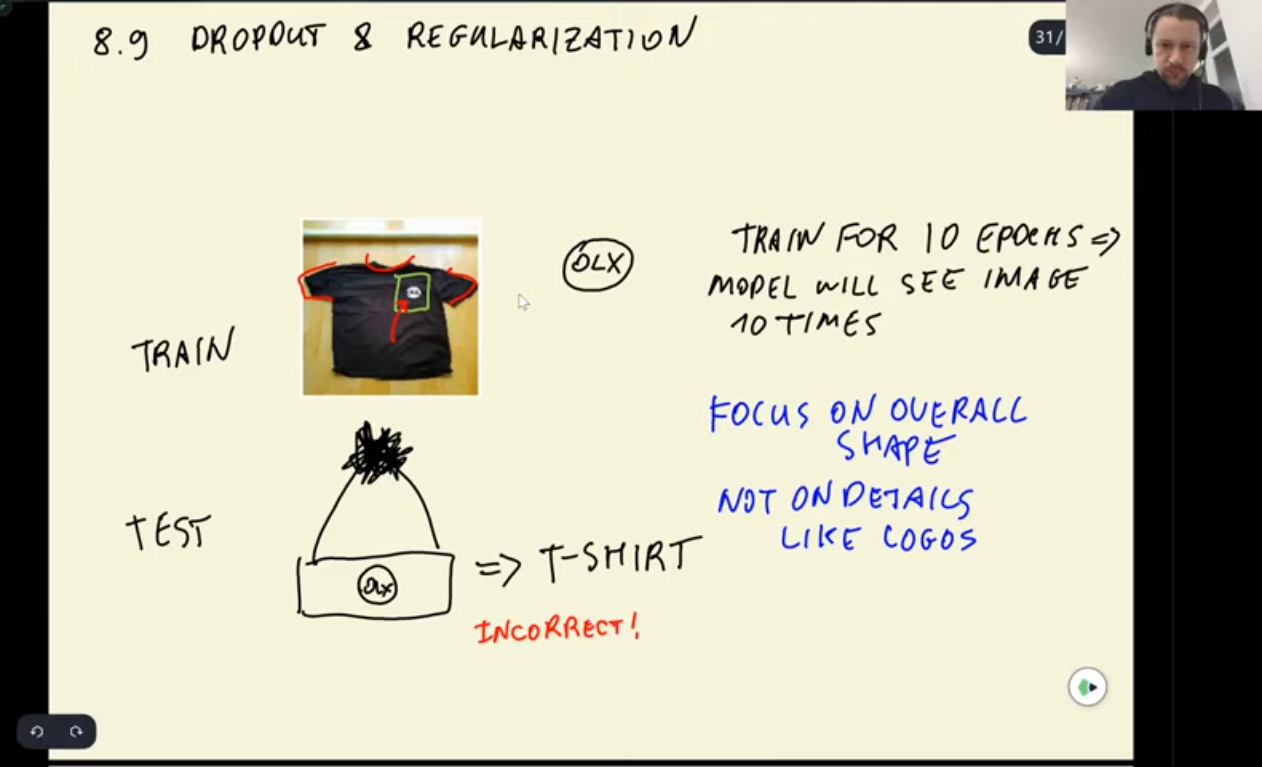

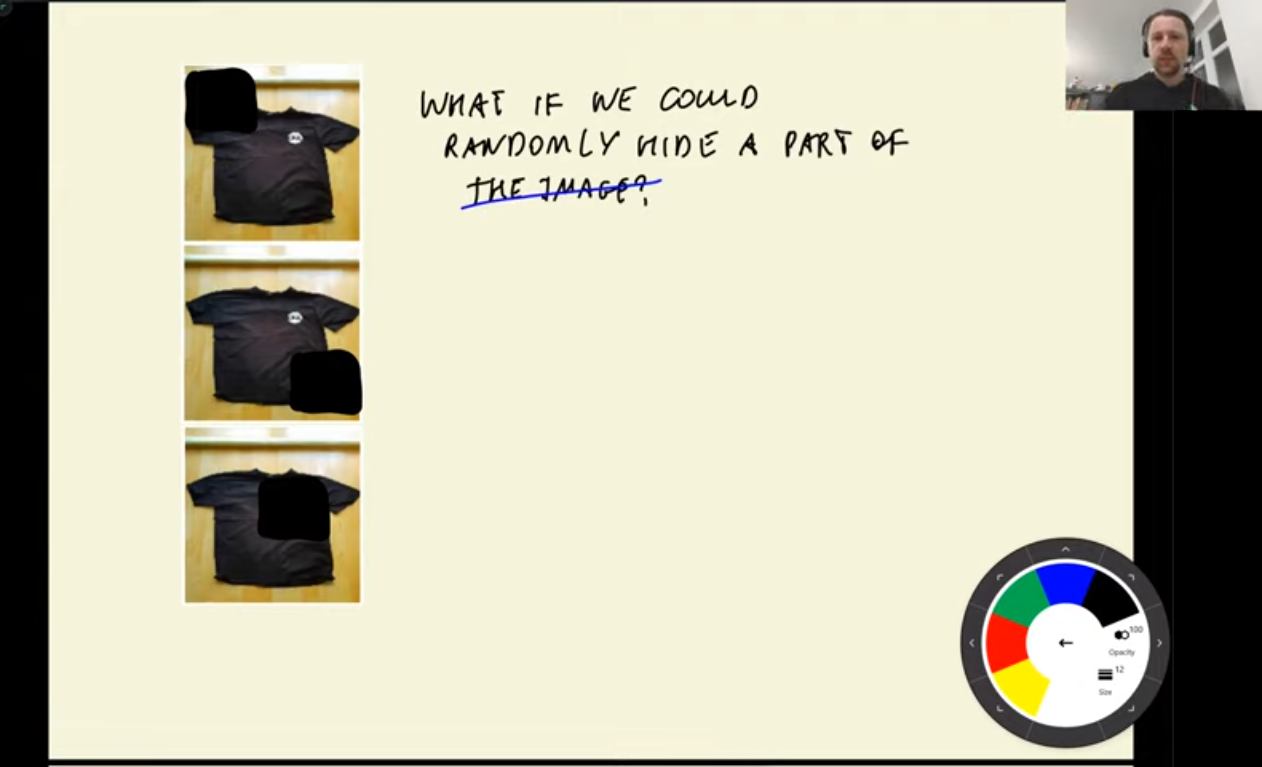

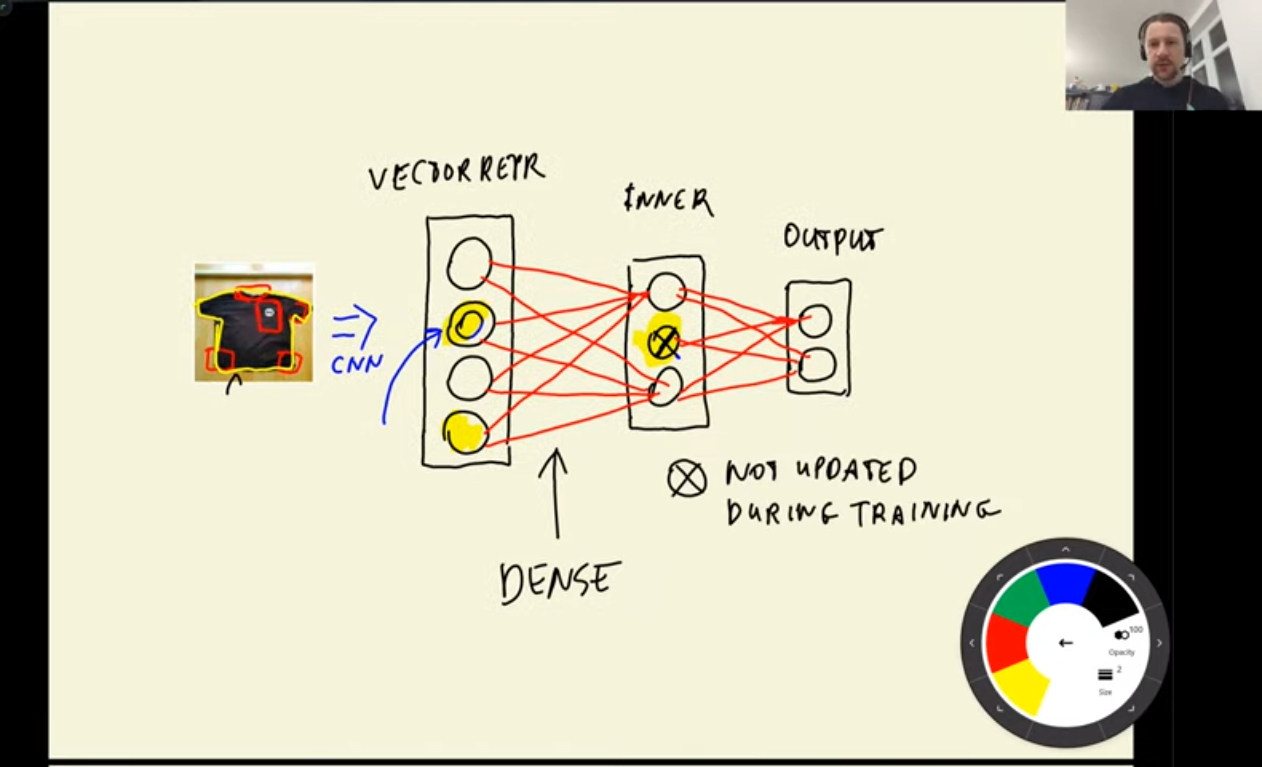

In [56]:
# Adding regularization

def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(150, 150, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    # New layers
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    # Dropout
    drop = keras.layers.Dropout(droprate)(inner)

    # Output layer
    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy'])

    return model

In [57]:
# Training - itterate over different values of layer size
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate)

    # Adding the number of epochs because the network cannot learn well now
    # due to dropout
    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 219ms/step - accuracy: 0.5918 - loss: 1.2209 - val_accuracy: 0.7830 - val_loss: 0.6297
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8423 - loss: 0.4689 - val_accuracy: 0.7859 - val_loss: 0.5955
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9012 - loss: 0.3242 - val_accuracy: 0.8065 - val_loss: 0.5689
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9322 - loss: 0.2285 - val_accuracy: 0.7918 - val_loss: 0.6271
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9472 - loss: 0.1921 - val_accuracy: 0.8240 - val_loss: 0.5494
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9831 - loss: 0.1037 - val_accuracy: 0.8094 - val_loss: 0.6122
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9943 - loss: 0.0715 - val_accuracy: 0.8270 - val_loss: 0.5649
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9948 - loss: 0.0525 - val_accuracy: 0.82

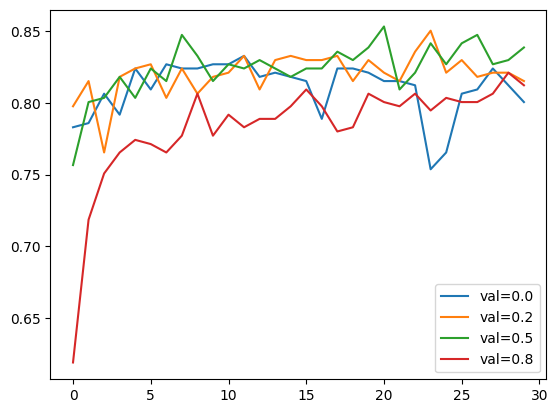

In [58]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.legend()

### 8.10 Data augmentation

The idea is to generate new images from existing images:
*   Transform (flip)
*   Rotation
*   Shift (height or width)
*   Shear (pulling a corner down)
*   Zoom (x or y)
*   Brightness / contrast
*   Black patch


In [60]:
# Augmentations are applied only to training
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               #rotation_range=30,
                               #width_shift_range=10.0,
                               #height_shift_range=10.0,
                               shear_range=10.0,
                               zoom_range=0.1,
                               vertical_flip=True)

train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train',
                                         target_size=(150, 150),
                                         batch_size=32)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory('./clothing-dataset-small/validation',
                                       target_size=(150, 150),
                                       batch_size=32,
                                       shuffle=False)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [61]:
# Training - itterate over different values of layer size
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

# Adding more epochs due to many parameters
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 49s 416ms/step - accuracy: 0.4772 - loss: 1.5778 - val_accuracy: 0.7507 - val_loss: 0.8028
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.6840 - loss: 0.9482 - val_accuracy: 0.7419 - val_loss: 0.7554
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.7328 - loss: 0.8050 - val_accuracy: 0.7801 - val_loss: 0.6419
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.7561 - loss: 0.7196 - val_accuracy: 0.7947 - val_loss: 0.6497
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.7776 - loss: 0.6550 - val_accuracy: 0.7889 - val_loss: 0.6551
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 260ms/step - accuracy: 0.7902 - loss: 0.5975 - val_accuracy: 0.7859 - val_loss: 0.6431
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.8123 - loss: 0.5610 - val_accuracy: 0.8035 - val_loss: 0.6179
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.8140 - loss: 0.5702 - val_accu

### 8.11 Training a larger model

In [67]:
# Training a larger model

def make_model(input_size=150, learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(input_size, input_size, 3)
    )

    base_model.trainable=False

    ###############################################################

    inputs = keras.Input(shape=(input_size, input_size, 3))

    # Apply base model to inputs and get something we will call Base
    base = base_model(inputs, training=False)

    # Or even better - using functional style
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    # New layers
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    # Dropout
    drop = keras.layers.Dropout(droprate)(inner)

    # Output layer
    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ###############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True) # We use raw score, without activation

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy'])

    return model

In [74]:
# Augmentations are applied only to training
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               shear_range=10.0,
                               zoom_range=0.1,
                               vertical_flip=True)

train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train',
                                         target_size=(299, 299),
                                         batch_size=32)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory('./clothing-dataset-small/validation',
                                       target_size=(299, 299),
                                       batch_size=32,
                                       shuffle=False)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [75]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [76]:
# Training - itterate over different values of layer size
learning_rate = 0.001
size = 100
droprate = 0.2
input_size = 299

model = make_model(
    input_size=299,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

# Adding more epochs due to many parameters
history = model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[checkpoint])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.5170 - loss: 1.4556

96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.5182 - loss: 1.4520 - val_accuracy: 0.8065 - val_loss: 0.5562
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.7689 - loss: 0.6866

96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 837ms/step - accuracy: 0.7690 - loss: 0.6864 - val_accuracy: 0.8211 - val_loss: 0.4977
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.8153 - loss: 0.5601

96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 843ms/step - accuracy: 0.8152 - loss: 0.5603 - val_accuracy: 0.8416 - val_loss: 0.4445
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.8219 - loss: 0.5147

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 842ms/step - accuracy: 0.8631 - loss: 0.4221 - val_accuracy: 0.8592 - val_loss: 0.3915
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.8677 - loss: 0.3889

96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 836ms/step - accuracy: 0.8678 - loss: 0.3889 - val_accuracy: 0.8680 - val_loss: 0.3926
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 838ms/step - accuracy: 0.8623 - loss: 0.4144 - val_accuracy: 0.8475 - val_loss: 0.3996
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 79s 818ms/step - accuracy: 0.8915 - loss: 0.3605 - val_accuracy: 0.8680 - val_loss: 0.3675
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 79s 825ms/step - accuracy: 0.8930 - loss: 0.3168 - val_accuracy: 0.8622 - val_loss: 0.3939
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 834ms/step - accuracy: 0.8978 - loss: 0.2974 - val_accuracy: 0.8680 - val_loss: 0.3986
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 79s 824ms/step - accuracy: 0.8993 - loss: 0.2933 - val_accuracy: 0.8592 - val_loss: 0.4078
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 795ms/step - accuracy: 0.9126 - loss: 0.2831 - val_accuracy: 0.8622 - val_loss: 0.4219
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 78s 814ms/step - accuracy: 0.8954 - loss: 0.2881 - val_accuracy:

96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 788ms/step - accuracy: 0.9185 - loss: 0.2305 - val_accuracy: 0.8798 - val_loss: 0.3937
Epoch 19/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 791ms/step - accuracy: 0.9146 - loss: 0.2367 - val_accuracy: 0.8504 - val_loss: 0.4527
Epoch 20/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 775ms/step - accuracy: 0.9089 - loss: 0.2601 - val_accuracy: 0.8710 - val_loss: 0.4170
Epoch 21/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 771ms/step - accuracy: 0.9260 - loss: 0.2217 - val_accuracy: 0.8475 - val_loss: 0.4446
Epoch 22/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 779ms/step - accuracy: 0.9290 - loss: 0.2003 - val_accuracy: 0.8680 - val_loss: 0.4316
Epoch 23/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 782ms/step - accuracy: 0.9362 - loss: 0.1914 - val_accuracy: 0.8739 - val_loss: 0.4409
Epoch 24/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 777ms/step - accuracy: 0.9427 - loss: 0.1686 - val_accuracy: 0.8651 - val_loss: 0.4525
Epoch 25/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9326 - loss: 0.1976

96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 784ms/step - accuracy: 0.9326 - loss: 0.1976 - val_accuracy: 0.8827 - val_loss: 0.4239
Epoch 26/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 772ms/step - accuracy: 0.9212 - loss: 0.2046 - val_accuracy: 0.8798 - val_loss: 0.4361
Epoch 27/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 767ms/step - accuracy: 0.9447 - loss: 0.1687 - val_accuracy: 0.8768 - val_loss: 0.4369
Epoch 28/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 774ms/step - accuracy: 0.9294 - loss: 0.1984 - val_accuracy: 0.8651 - val_loss: 0.4743
Epoch 29/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 750ms/step - accuracy: 0.9413 - loss: 0.1670 - val_accuracy: 0.8710 - val_loss: 0.4400
Epoch 30/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 736ms/step - accuracy: 0.9553 - loss: 0.1342 - val_accuracy: 0.8534 - val_loss: 0.4854
Epoch 31/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 771ms/step - accuracy: 0.9466 - loss: 0.1616 - val_accuracy: 0.8534 - val_loss: 0.4791
Epoch 32/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 786ms/step - accuracy: 0.9460 - loss: 0.1561 - val_accuracy

KeyboardInterrupt: 

### 8.12 Using the model